### This notebook calculates the reliability of task beta values across runs and compares them in two models:
- Obtained from a GLM with only instruction and task regresssors.
- Obtained from a GLM with instruction + task + RETROICOR regressors.

In [12]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm
from scipy.stats import pearsonr
import SUITPy as suit
import matplotlib.pyplot as plt
import nitools as nt
import cortico_cereb_connectivity.summarize as cs
from nilearn import plotting
from scipy.stats import ttest_rel

### Setup

In [13]:
# Parameters
subjects = ['sub-05', 'sub-07', 'sub-08', 'sub-09', 'sub-11', 'sub-12', 'sub-13', 'sub-16', 
'sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-25', 'sub-27']
n_runs = 8
n_tasks = 18
models = ["glm_task1_retro0_hr0", "glm_task1_retro1_hr0"]
# models = ["glm_task1_retro1_hr0"]
# models = ["glm_task1_retro0_hr0"]

base_dir = "/cifs/diedrichsen/data/Cerebellum/Social/data/GLM_physio"
mask_dir = "/cifs/diedrichsen/data/Cerebellum/Social/data/imaging_data"
out_dir = f"{base_dir}/reliability_maps"
os.makedirs(out_dir, exist_ok=True)

In [14]:
def load_betas(subject, run, model, subj_dir=None):
    if subj_dir is None:
        subj_dir = os.path.join(base_dir, model, subject)
    else:
        subj_dir = os.path.join(subj_dir, subject)

    if model == "glm_task1_retro0_hr0":
        betas_per_run = 19  # 1 instruction + 18 task
        task_idx = list(range(2, 20))  # betas 2–19
    elif model == "glm_task1_retro1_hr0":
        betas_per_run = 25  # 1 instruction + 18 task + 6 retro
        task_idx = list(range(2, 20))  # betas 2–19
    else:
        raise ValueError("Model must be 'glm_task1_retro0_hr0' or 'glm_task1_retro1_hr0'")

    # figure out which beta files belong to this run
    start = (run - 1) * betas_per_run + 1
    files = [os.path.join(subj_dir, f"beta_{start + idx - 1:04d}.nii") for idx in task_idx]

    # load them and stack
    imgs = [nib.load(f) for f in files]
    data = np.stack([img.get_fdata() for img in imgs], axis=-1)  # (X,Y,Z,18)
    return imgs[0], data

In [4]:
def voxelwise_reliability_loo(run_betas):
    """
    Vectorized LOO reliability.
    run_betas: list of arrays [n_voxels, n_tasks] for each run
    Returns: reliability map [n_voxels]
    """
    runs = np.stack(run_betas, axis=0)
    n_runs, n_vox, n_tasks = runs.shape
    reliab = np.zeros(n_vox)

    # Precompute valid voxels (finite in all runs)
    valid_vox = np.isfinite(runs).all(axis=(0, 2))  # (n_vox,)

    for i in tqdm(range(n_runs), desc="      LOO reliability"):
        # leave-one-out mean (over runs except i)
        loo_mean = runs[np.arange(n_runs) != i].mean(axis=0)  # (n_vox, n_tasks)
        x = runs[i]  # (n_vox, n_tasks)

        # only valid voxels
        mask = np.where(valid_vox)[0]

        # fast correlation per voxel
        xm = x[mask] - x[mask].mean(axis=1, keepdims=True)
        ym = loo_mean[mask] - loo_mean[mask].mean(axis=1, keepdims=True)

        denom = np.linalg.norm(xm, axis=1) * np.linalg.norm(ym, axis=1)
        r = np.sum(xm * ym, axis=1) / denom
        r[denom == 0] = np.nan

        reliab[mask] += r

    reliab[valid_vox] /= n_runs
    reliab[~valid_vox] = np.nan
    return reliab

### Calculate reliability maps

In [ ]:
for subj in subjects:
    print(f"\nProcessing subject {subj}")

    # load noskull mask
    mask_img = nib.load(os.path.join(mask_dir, subj, "ses-01", "rmask_noskull.nii"))
    mask_data = mask_img.get_fdata().astype(bool)
    mask_idx = np.where(mask_data.ravel())[0]

    for model in models:
        print(f"  - Model: {model}")

        # Load betas for all runs
        run_betas = []
        for run in range(1, n_runs + 1):
            _, data = load_betas(subj, run, model)

            # reshape and apply mask
            n_x, n_y, n_z, n_tasks = data.shape
            reshaped_data = data.reshape(-1, n_tasks)[mask_idx]
            run_betas.append(reshaped_data)
        print(f"      Loaded betas")

        # Compute LOO reliability
        reliab_masked = voxelwise_reliability_loo(run_betas)

        # map back to full brain
        reliab_full = np.full(mask_data.size, np.nan)
        reliab_full[mask_idx] = reliab_masked
        reliab_map = reliab_full.reshape(n_x, n_y, n_z)

        # Save NIfTI
        out_img = nib.Nifti1Image(reliab_map, affine=mask_img.affine)
        out_path = os.path.join(out_dir, f"{subj}_{model}_reliability.nii")
        nib.save(out_img, out_path)

        print(f"      Saved {out_path}")

#### Plot the reliability maps

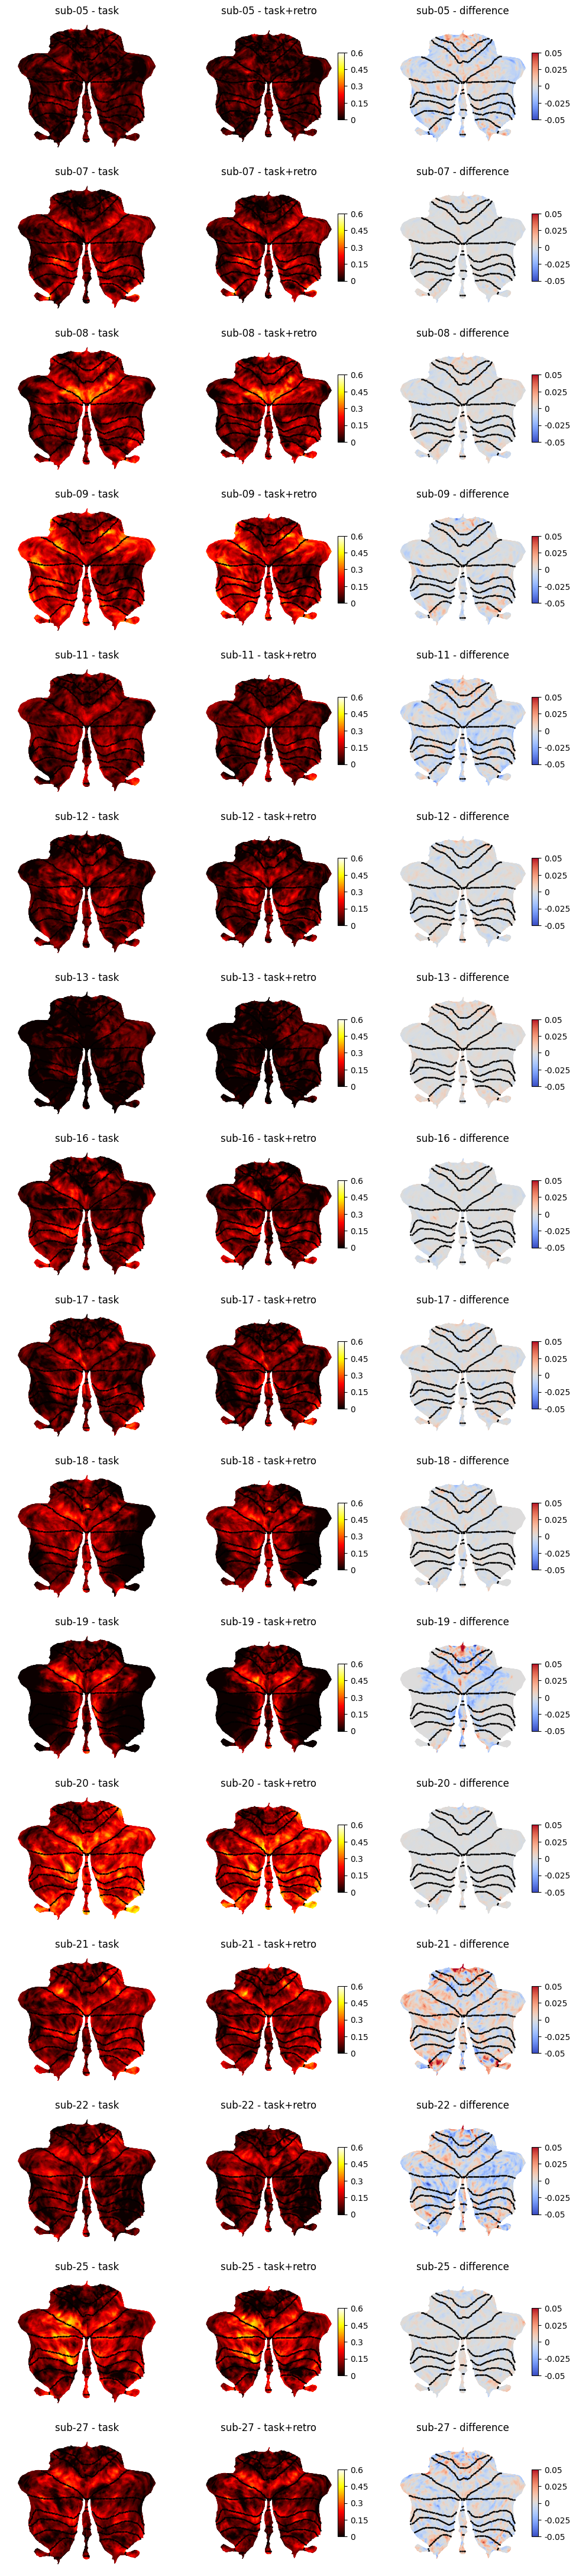

In [25]:
fig, axes = plt.subplots(len(subjects), 3, figsize=(4*3, 3.5 * len(subjects)))
axes = axes.reshape(len(subjects), 3)
for s, sub in enumerate(subjects):
    for m, model in enumerate(models):
        file_path = os.path.join(out_dir, 'SUIT', f"w{sub}_{model}_reliability.nii")
        nifti_img = nib.load(file_path)

        # project to SUIT flatmap
        cereb_surf = suit.vol_to_surf(nifti_img, space='MNISymC')
        plt.subplot(len(subjects), 3, s*3 + m + 1)
            
        if m == 0:
            suit.flatmap.plot(cereb_surf, cmap='hot', new_figure=False, cscale=[0, 0.6])
            last_surf = cereb_surf
            axes[s, m].set_title(f"{sub} - task")
        else:
            suit.flatmap.plot(cereb_surf, cmap='hot', new_figure=False, cscale=[0, 0.6], colorbar=True)
            axes[s, m].set_title(f"{sub} - task+retro")
        
    plt.subplot(len(subjects), 3, s*3 + 3)
    suit.flatmap.plot(cereb_surf-last_surf, cmap='coolwarm', new_figure=False, cscale=[-0.05, 0.05], colorbar=True)
    axes[s, 2].set_title(f"{sub} - difference")


### Summary DataFrame

In [18]:
rel_df = pd.DataFrame(columns=['subject', 'mean_rel_task', 'mean_rel_task_retro', 'corr'])

# load all reliability maps
for s, sub in enumerate(subjects):
    nifti_img = nib.load(os.path.join(out_dir, 'SUIT', f"w{sub}_glm_task1_retro0_hr0_reliability.nii"))
    data_1 = nifti_img.get_fdata()
    mean_rel_1 = np.nanmean(data_1)

    nifti_img = nib.load(os.path.join(out_dir, 'SUIT', f"w{sub}_glm_task1_retro1_hr0_reliability.nii"))
    data_2 = nifti_img.get_fdata()
    mean_rel_2 = np.nanmean(data_2)

    # Handle NaNs: only correlate where both maps are finite
    mask = np.isfinite(data_1) & np.isfinite(data_2)
    if np.any(mask):
        corr = np.corrcoef(data_1[mask].flatten(), data_2[mask].flatten())[0, 1]
    else:
        corr = np.nan

    rel_df.loc[s] = [sub, mean_rel_1, mean_rel_2, corr]

In [19]:
# paired t-test
t_stat, p_val = ttest_rel(rel_df['mean_rel_task'], rel_df['mean_rel_task_retro'])
print(f"Paired t-test: t = {t_stat:.4f}, p = {p_val:.4g}")

Paired t-test: t = 0.6001, p = 0.5574


In [20]:
print(rel_df)

   subject  mean_rel_task  mean_rel_task_retro      corr
0   sub-05       0.046472             0.045751  0.990221
1   sub-07       0.093580             0.093566  0.999349
2   sub-08       0.114457             0.114508  0.999299
3   sub-09       0.108554             0.108137  0.997825
4   sub-11       0.074782             0.073552  0.994315
5   sub-12       0.061250             0.061115  0.998992
6   sub-13       0.037292             0.037731  0.998580
7   sub-16       0.067094             0.067025  0.999550
8   sub-17       0.069685             0.069814  0.999113
9   sub-18       0.076122             0.075614  0.999074
10  sub-19       0.076467             0.076265  0.991387
11  sub-20       0.107690             0.107563  0.999650
12  sub-21       0.091491             0.094508  0.986686
13  sub-22       0.069416             0.066986  0.988378
14  sub-25       0.110922             0.110782  0.999055
15  sub-27       0.087841             0.087613  0.992718
